In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/PhD/MatrixProductBP.jl/results_for_article`


In [2]:
using JLD2, Plots, Statistics, LaTeXStrings, MatrixProductBP, Tullio
using UnPack: @unpack
blue = palette(:tab10)[1]
orange = palette(:tab10)[2]
green = palette(:tab10)[3]
red = palette(:tab10)[4]
brown = "#893606"
beige = "#efe7dd"
beige2 = "#f2f1ec"
cyan = "#289dd2"
;

## Random tree (preferential attachment) with random couplings

In [25]:
N = 100
D = load("./tree_$(N)_beta0,5_h0_randomJ.jld2")
m_fourier = D["m_fourier"]
energy_fourier = D["energy_fourier"]
J = D["J"]

nsamp = [10^5]
m_mc = []
energy_mc = []
for n in nsamp
    D = load("./monte_carlo_tree_$(N)_randomJ_beta0,5_h0_nsamp$(n).jld2")
    push!(m_mc, D["m_mc"])
    push!(energy_mc, D["energy_mc"])
end

col = cgrad(:OrRd_7, length(nsamp)+1, categorical=true)[2:end]
T = length(m_fourier) - 1
;

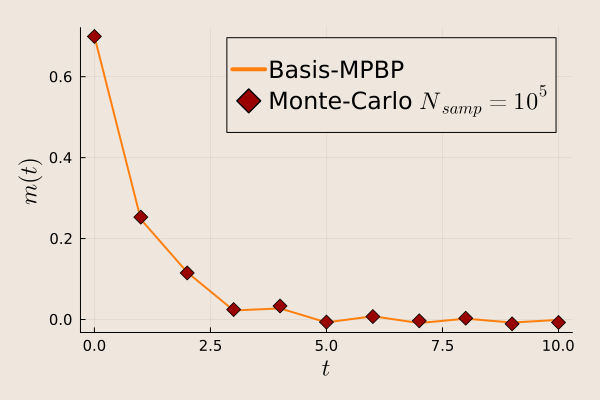

In [26]:
i = 1
y_mc = m_mc[end][i]
y_fourier = m_fourier[i]

T = length(y_fourier) - 1
pltree = plot(legend=:topright, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=16,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t",
            ylabel=L"m(t)",
            bg_color=beige)

plot!(pltree, 0:T, y_fourier[1:end], color=orange, lw=2, label="Basis-MPBP")
logmc = Int(log10(nsamp[end]))
plot!(pltree, 0:T, y_mc[1:end], color=col[end], st=:scatter, marker=:diamond, markersize=7, label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}")

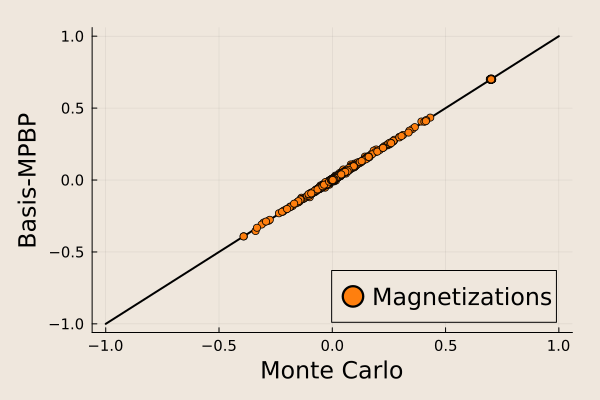

In [5]:
y_fourier_sc = reduce(vcat, y for y in m_fourier)
y_mc_sc = reduce(vcat, y for y in m_mc[end])
pl2tree = plot(legend=:bottomright, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=16,
            tickfontsize=10,
            size=(600,400),
            xlabel="Monte Carlo",
            ylabel="Basis-MPBP",
            bg_color=beige)

plot!(pl2tree, -1.0:0.1:1.0, -1.0:0.1:1.0, label="", c=:black, lw=2)
plot!(pl2tree, y_mc_sc, y_fourier_sc, st=:scatter, markerstrokecolor=:black, color=orange, label="Magnetizations")

In [27]:
savefig(pltree, "figures/tree_magnetization_single_node.svg")
savefig(pl2tree, "figures/tree_magnetization_scatter.svg")

"/home/fedflorio/PhD/MatrixProductBP.jl/results_for_article/figures/tree_magnetization_scatter.svg"

## Infinite regular graph with random couplings

In [7]:
D = load("./infinite_8-reg_beta0,3_dmax15_K60.jld2")

beliefs = D["bs"]
beliefs2times = D["bs2times"]
beliefs2vars = D["bs2vars"]


Nmc = 5*10^3
nsamp = [10^4, 10^5, 10^6]
m_mc = []
autocorr_mc = []
energy_mc = []
for n in nsamp
    D = load("./monte_carlo_infinite_8-reg_beta0,3_Nmc$(Nmc)_nsamp$(n).jld2")
    push!(m_mc, D["m_mc"])
    push!(autocorr_mc, D["autocorr_mc"])
    push!(energy_mc, D["energy_mc"])
end

T = length(beliefs[1]) - 1
col = cgrad(:OrRd_7, length(nsamp)+1, categorical=true)[2:end]
;

In [8]:
import MatrixProductBP.Models: potts2spin
ns = 1500
range = length(beliefs)+1-min(ns, length(beliefs)):length(beliefs)
ms = [expectation.(potts2spin, b) for b in beliefs[range]]
m_fourier = mean(ms)
σ_fourier = std(ms) ./ sqrt(length(ms))

rs = [expectation.(potts2spin, btu) for btu in beliefs2times[range]]
cs = MatrixProductBP.covariance.(rs, ms)
c_avg = mean(abs.(x) for x in cs)
c_std = std(cs) ./ sqrt(length(cs))

degree = 4
ns2vars = ns * degree
range = length(beliefs2vars)+1-min(ns2vars, length(beliefs2vars)):length(beliefs2vars)
c2s = []

function p2(X)
    @tullio _[xᵢᵗ⁺¹, xⱼᵗ] := X[xᵢᵗ,xⱼᵗ,xᵢᵗ⁺¹,xⱼᵗ⁺¹]
end
for b2v in @view beliefs2vars[range]
    Jⱼᵢ = b2v[2]
    X = b2v[1]
    push!(c2s, Jⱼᵢ.*[expectation(potts2spin, p2(x)) for x in X])
end
c2_avg = mean(c2s)
c2_std = std(c2s) ./ sqrt(length(c2s))
;

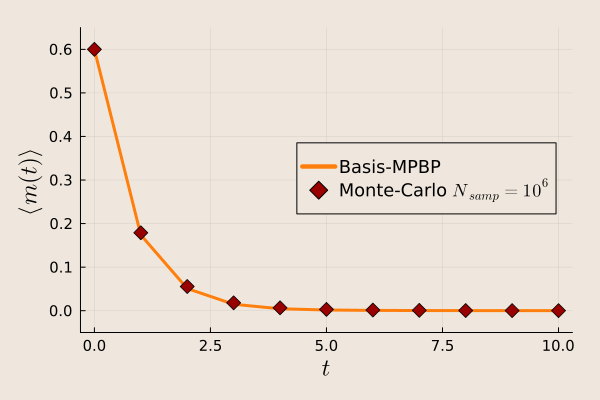

In [9]:
y_mc = m_mc[end]
y_fourier = -m_fourier

T = length(y_fourier) - 1
plrr = plot(legend=:right, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=12,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t",
            ylabel=L"\langle m(t) \rangle",
            ylim=(-0.05, 0.65),
            bg_color=beige)

plot!(plrr, 0:T, y_fourier[1:end], color=orange, ribbon=σ_fourier, lw=3, label="Basis-MPBP")
logmc = Int(log10(nsamp[end]))
plot!(plrr, 0:T, y_mc[1:end], color=col[end], st=:scatter, marker=:diamond, markersize=7, label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}")
display(plrr)

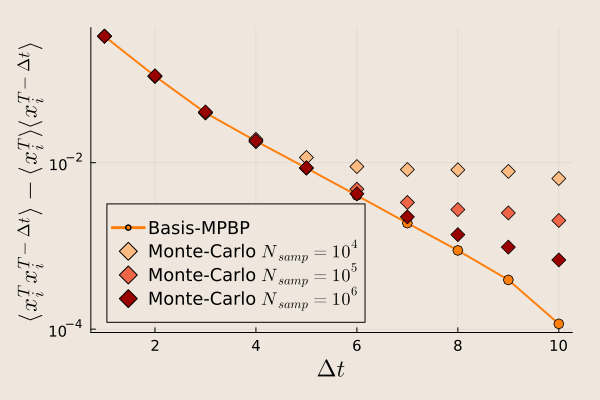

In [10]:
pl2rr = plot(legend=:bottomleft, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=12,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"\Delta t",
            ylabel=L"\langle x_{i}^T x_{i}^{T-\Delta t}\rangle-" * 
            L"\langle x_{i}^T\rangle\langle x_{i}^{T-\Delta t}\rangle", 
            yaxis=:log,
            bg_color=beige)

plot!(pl2rr, T:-1:1, c_avg[1:1:10,11]; skip_even=true, m=:o, us=4:2:T, label="Basis-MPBP", color=orange, lw=2, markersize=5)

for (k,N) in enumerate(nsamp)
    logmc = Int(log10(N))
    plot!(T:-1:1, autocorr_mc[k][1:1:end-1], st=:scatter, marker=:diamond, color=col[k], markersize=7, label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}")
end

display(pl2rr)

In [11]:
savefig(plrr, "figures/rr_magnetization_single_node.svg")
savefig(pl2rr, "figures/rr_autocorrelation.svg")

"/home/fedflorio/PhD/MatrixProductBP.jl/results_for_article/figures/rr_autocorrelation.svg"

## Infinite Erdős-Rényi graph with random couplings

In [12]:
D = load("./infinite_er_beta0,5_dmax15_K60.jld2")

beliefs = D["bs"]
beliefs2times = D["bs2times"]
beliefs2vars = D["bs2vars"]


Nmc = 5*10^3
nsamp = [10^4, 10^5, 10^6]
# nsamp = [10^4, 10^5, 10^6]
m_mc = []
autocorr_mc = []
energy_mc = []
for n in nsamp
    D = load("./monte_carlo_infinite_er_beta0,5_Nmc$(Nmc)_nsamp$(n).jld2")
    push!(m_mc, D["m_mc"])
    push!(autocorr_mc, D["autocorr_mc"])
    push!(energy_mc, D["energy_mc"])
end

T = length(beliefs[1]) - 1
col = cgrad(:OrRd_7, length(nsamp)+1, categorical=true)[2:end]
;

In [13]:
import MatrixProductBP.Models: potts2spin
ns = 1500
range = length(beliefs)+1-min(ns, length(beliefs)):length(beliefs)
ms = [expectation.(potts2spin, b) for b in beliefs[range]]
m_fourier = mean(ms)
σ_fourier = std(ms) ./ sqrt(length(ms))

rs = [expectation.(potts2spin, btu) for btu in beliefs2times[range]]
cs = MatrixProductBP.covariance.(rs, ms)
c_avg = mean(abs.(x) for x in cs)
c_std = std(cs) ./ sqrt(length(cs))

degree = 4
ns2vars = ns * degree
range = length(beliefs2vars)+1-min(ns2vars, length(beliefs2vars)):length(beliefs2vars)
c2s = []

function p2(X)
    @tullio _[xᵢᵗ⁺¹, xⱼᵗ] := X[xᵢᵗ,xⱼᵗ,xᵢᵗ⁺¹,xⱼᵗ⁺¹]
end
for b2v in @view beliefs2vars[range]
    Jⱼᵢ = b2v[2]
    X = b2v[1]
    push!(c2s, Jⱼᵢ.*[expectation(potts2spin, p2(x)) for x in X])
end
c2_avg = mean(c2s)
c2_std = std(c2s) ./ sqrt(length(c2s))
;

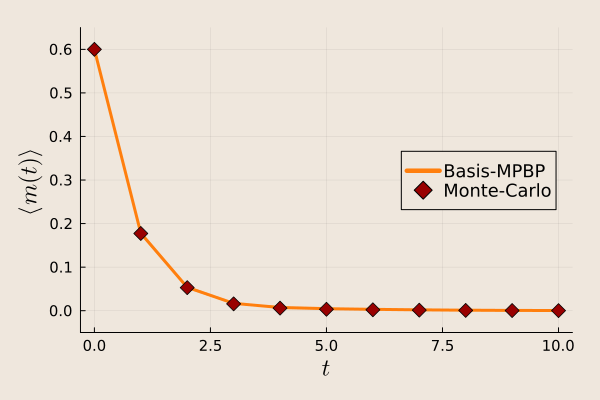

In [14]:
y_mc = m_mc[end]
y_fourier = -m_fourier

pler = plot(legend=:right, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=12,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t",
            ylabel=L"\langle m(t) \rangle",
            ylim=(-0.05, 0.65),
            bg_color=beige)


plot!(pler, 0:T, y_fourier[1:end], color=orange, ribbon=σ_fourier, lw=3, label="Basis-MPBP")
plot!(pler, 0:T, y_mc[1:end], color=col[end], st=:scatter, marker=:diamond, markersize=7, label="Monte-Carlo")
display(pler)

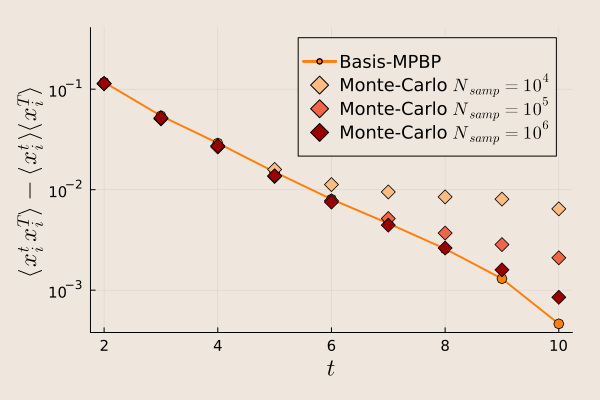

In [15]:
pl2er = plot(legend=:topright, margin=5Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=12,
            tickfontsize=10,
            size=(600,400),
            xlabel=L"t",
            ylabel=L"\langle x_{i}^t x_{i}^{T}\rangle-" * 
            L"\langle x_{i}^t\rangle\langle x_{i}^{T}\rangle", 
            yaxis=:log,
            bg_color=beige)

plot!(pl2er, T:-1:2, c_avg[1:1:9,11]; skip_even=true, m=:o, us=4:2:T, label="Basis-MPBP", color=orange, lw=2, markersize=5)
for (k,N) in enumerate(nsamp)
    logmc = Int(log10(N))
    plot!(T:-1:2, autocorr_mc[k][1:1:end-1], st=:scatter, marker=:diamond, color=col[k], markersize=7, label="Monte-Carlo "*L"N_{samp}=10^{%$logmc}")
end

display(pl2er)

In [16]:
savefig(pler, "figures/er_magnetization_single_node.svg")
savefig(pl2er, "figures/er_autocorrelation.svg")

"/home/fedflorio/PhD/MatrixProductBP.jl/results_for_article/figures/er_autocorrelation.svg"

## Large deviations (reweighting at final time)

In [17]:
import MatrixProductBP.Models: potts2spin

bs = []
fs = []
ms = []

for cnt in -24:3:24
    D = load("./infinite_8-reg_reweight_h$(cnt)_dmax10_K30.jld2")
    beliefs = D["bs"]
    free_energies = D["fs"]
    push!(bs, D["bs"])

    ns = 4000
    range = length(beliefs)+1-min(ns, length(beliefs)):length(beliefs)
    mag = [expectation.(potts2spin, b) for b in beliefs[range]]
    range_f = length(free_energies)+1-min(ns, length(free_energies)):length(free_energies)
    f = mean(free_energies[range_f])
    push!(ms, mean(mag))
    push!(fs, f)
end

hs = -0.24:0.03:0.24 |> collect
msend = [-m[end] for m in ms]
;

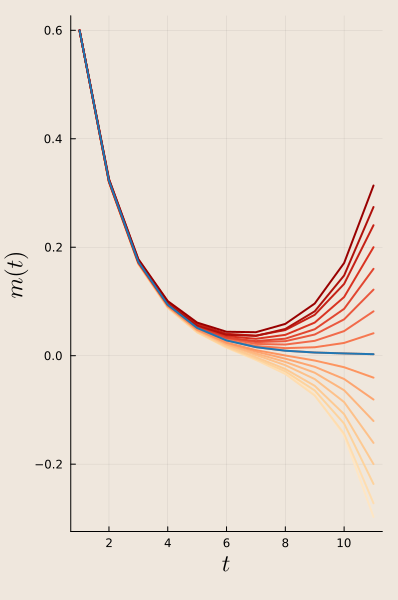

In [29]:
col = cgrad(:OrRd_7, length(hs)+1, categorical=true)[2:end]

pl1ld = plot(xlabel="t", ylabel="m(t)", lw=2, legend=false)
pl1ld = plot(legend=false, margin=2Plots.mm,
            xlabelfontsize=16,
            ylabelfontsize=16,
            legendfontsize=10,
            tickfontsize=8,
            size=(400,600),
            xlabel=L"t",
            ylabel=L"m(t)",
            bg_color=beige)
            # ylim=(-0.2, 0.3))

for (k,h) in enumerate(hs)
    plot!(pl1ld, -ms[k], color=col[k], lw=2)
end
plot!(pl1ld, -ms[9], color=blue, lw=2)

display(pl1ld)

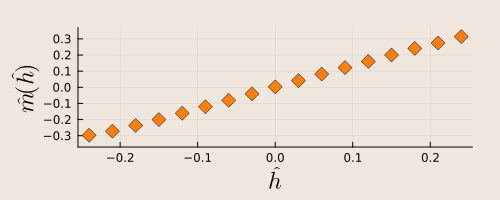

In [31]:
pl2ld = plot(hs, msend, 
            xlabel=L"\hat h", 
            ylabel=L"\hat m(\hat h)", 
            st=:scatter, 
            marker=:diamond, 
            markersize=7, 
            color=orange, 
            lw=2, 
            legend=false,
            xlabelfontsize=16,
            ylabelfontsize=16,
            ylim=(-0.37,0.37),
            size=(500,200),
            margin=5Plots.mm,
            bg_color=beige)

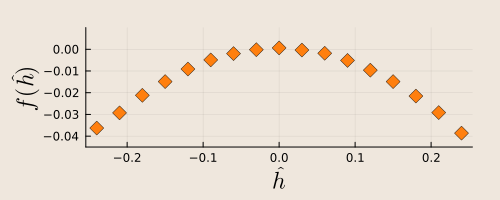

In [32]:
pl3ld = plot(hs, float.(fs), 
            xlabel=L"\hat h", 
            ylabel=L"f(\hat h)", 
            st=:scatter, 
            marker=:diamond, 
            markersize=7, 
            color=orange, 
            lw=2, 
            legend=false, 
            xlabelfontsize=16,
            ylabelfontsize=16,
            ylim=(-0.045,0.01),
            size=(500,200),
            margin=5Plots.mm,
            bg_color=beige)

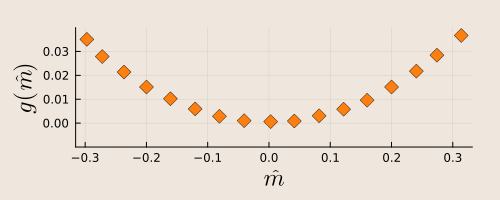

In [33]:
gs = fs .+ hs .* msend
pl4ld = plot(msend, gs, 
            xlabel=L"\hat m", 
            ylabel=L"g(\hat m)", 
            st=:scatter, 
            marker=:diamond, 
            markersize=7, 
            color=orange, 
            lw=2, 
            legend=false,
            xlabelfontsize=16,
            ylabelfontsize=16,
            ylim=(-0.01,0.04),
            size=(500,200),
            margin=5Plots.mm,
            bg_color=beige)

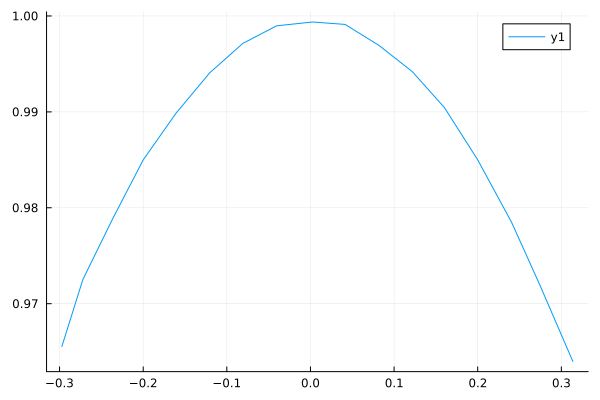

In [22]:
plot(msend, exp.(-gs))

In [34]:
savefig(pl1ld, "figures/ld_k8_magnetizations.svg")
savefig(pl2ld, "figures/ld_k8_m(h).svg")
savefig(pl3ld, "figures/ld_k8_f(h).svg")
savefig(pl4ld, "figures/ld_k8_g(m).svg")

"/home/fedflorio/PhD/MatrixProductBP.jl/results_for_article/figures/ld_k8_g(m).svg"